# Preparing the dataset

### Fetch dataset from drive and unzip locally

In [1]:
from google.colab import drive

# Mount google drive
drive.mount('/content/drive')

Mounted at /content/drive


Copy dataset from google drive to local colab environment. Training is much faster this way

Link to dataset: https://www.kaggle.com/datasets/alistairking/recyclable-and-household-waste-classification

In [2]:
import os

# Define the path to your zipped file in Google Drive
zipped_file_path = '/content/drive/MyDrive/WasteDataset.zip'

# Define the destination directory in your Colab environment
dataset_path = '/content/dataset/'

# Create the destination directory if it doesn't exist
os.makedirs(dataset_path, exist_ok=True)

In [3]:
# Copy the zipped file to the local Colab environment
!cp "{zipped_file_path}" "{dataset_path}"

In [4]:
# Change to the destination directory
%cd "{dataset_path}"

!unzip -q "{os.path.basename(zipped_file_path)}"

# Go back to the original content directory
%cd /content

/content/dataset
/content


In [5]:
# List the contents of the unzipped directory
!ls -F "{dataset_path}"

images/  README.txt  WasteDataset.zip


### Preprocess and load images
Note: Trying to load all images into memory at once consumes too much RAM, so images are loaded through their paths dynamically using tf dataset

In [6]:
import tensorflow as tf
import os

In [7]:
# Settings
dataset_root = "/content/dataset/images/images"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.1 # 10% validation
TEST_SPLIT = 0.1 # 10% test
SEED = 42

In [8]:
# Training dataset
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_root,
    validation_split=VAL_SPLIT + TEST_SPLIT, # 20% reserved for val+test
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical" # one-hot encoded labels
)

# Temp dataset: 20% reserved for val+test
temp_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_root,
    validation_split=VAL_SPLIT + TEST_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 15000 files belonging to 30 classes.
Using 12000 files for training.
Found 15000 files belonging to 30 classes.
Using 3000 files for validation.


In [9]:
# Convert to a list of batches for splitting
temp_images = []
temp_labels = []

for images, labels in temp_dataset:
    temp_images.append(images)
    temp_labels.append(labels)

# Concatenate all batches
temp_images = tf.concat(temp_images, axis=0)
temp_labels = tf.concat(temp_labels, axis=0)

# Compute split indices
num_temp = temp_images.shape[0]
num_val = int(num_temp * (VAL_SPLIT / (VAL_SPLIT + TEST_SPLIT)))

X_val = temp_images[:num_val]
y_val = temp_labels[:num_val]

X_test = temp_images[num_val:]
y_test = temp_labels[num_val:]

# Convert back to tf.data.Dataset
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [10]:
class_names = train_dataset.class_names
idx_to_class = {i: name for i, name in enumerate(class_names)}

print("Num Classes: ", len(class_names))
print("Classes:", class_names)
print("Number of training batches:", tf.data.experimental.cardinality(train_dataset).numpy())

Num Classes:  30
Classes: ['aerosol_cans', 'aluminum_food_cans', 'aluminum_soda_cans', 'cardboard_boxes', 'cardboard_packaging', 'clothing', 'coffee_grounds', 'disposable_plastic_cutlery', 'eggshells', 'food_waste', 'glass_beverage_bottles', 'glass_cosmetic_containers', 'glass_food_jars', 'magazines', 'newspaper', 'office_paper', 'paper_cups', 'plastic_cup_lids', 'plastic_detergent_bottles', 'plastic_food_containers', 'plastic_shopping_bags', 'plastic_soda_bottles', 'plastic_straws', 'plastic_trash_bags', 'plastic_water_bottles', 'shoes', 'steel_food_cans', 'styrofoam_cups', 'styrofoam_food_containers', 'tea_bags']
Number of training batches: 375


### Data Augmentation

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

# Apply augmentation to training dataset
augmented_train_dataset = train_dataset.map(lambda x, y: (data_augmentation(x, training=True), y))
augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

In [12]:
def count_images(dataset):
    count = 0
    for images, _ in dataset:
        count += images.shape[0]
    return count

In [13]:
# Final datasets to use
print("Train Dataset: ", train_dataset)
print("Augmented Train Dataset: ", augmented_train_dataset)
print("Train images count:", count_images(train_dataset))

print("Val Dataset: ", val_dataset)
print("Val images count:", count_images(val_dataset))

print("Test Dataset: ", test_dataset)
print("Test images count:", count_images(test_dataset))

Train Dataset:  <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 30), dtype=tf.float32, name=None))>
Augmented Train Dataset:  <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 30), dtype=tf.float32, name=None))>
Train images count: 12000
Val Dataset:  <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 30), dtype=tf.float32, name=None))>
Val images count: 1500
Test Dataset:  <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 30), dtype=tf.float32, name=None))>
Test images count: 1500


# Visualize the data

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def show_images(dataset, class_names=None):
    plt.figure(figsize=(8, 8))

    # Take one batch only
    for images, labels in dataset.take(1):
        for i in range(9):
            plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))

            if class_names is not None:
                label_idx = np.argmax(labels[i])
                plt.title(class_names[label_idx])

            plt.axis("off")

    plt.tight_layout()
    plt.show()


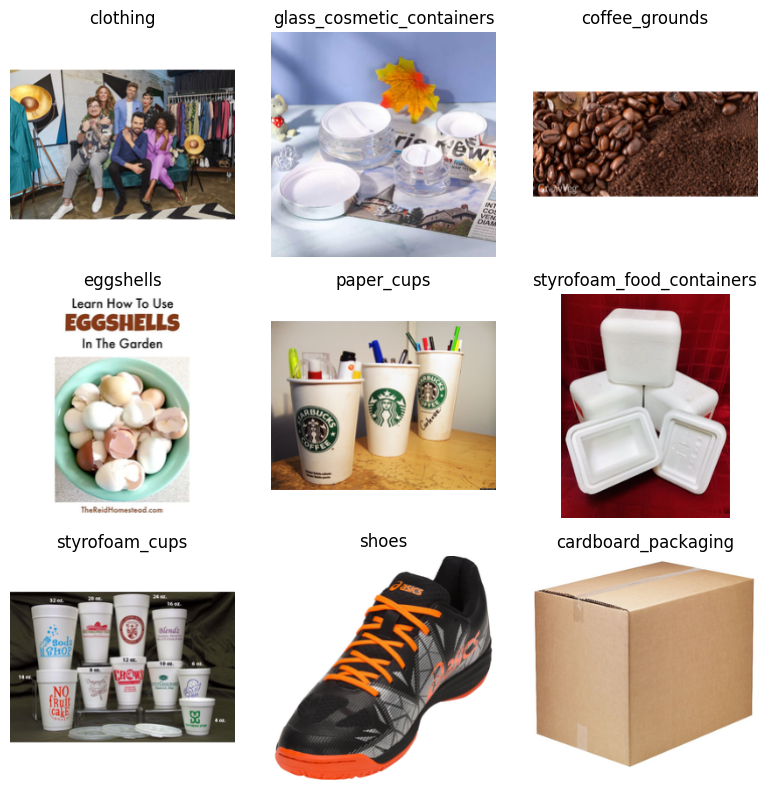

In [15]:
show_images(train_dataset, class_names)